In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
df=pd.read_csv('income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [17]:
datasubset=df.loc[:,['Age','Income($)']]

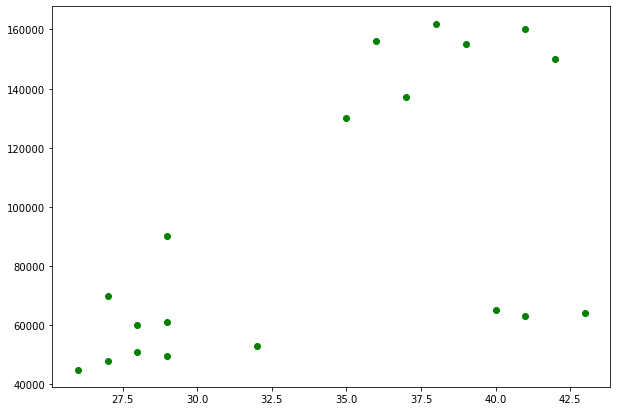

In [18]:
plt.figure(figsize=(10,7))
plt.scatter(datasubset[['Age']],datasubset[['Income($)']],c='green')

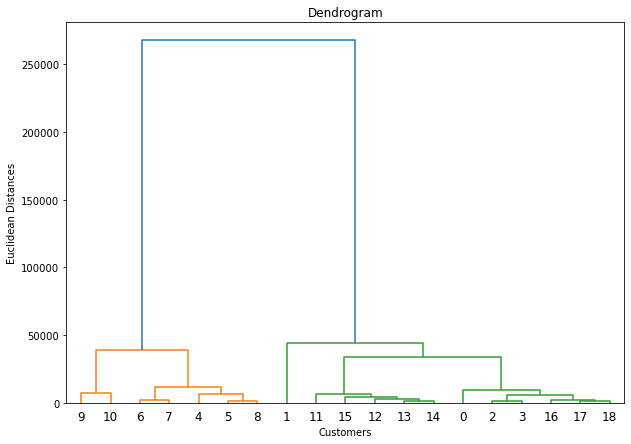

In [19]:
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(10,7))
dendrogram=sch.dendrogram(sch.linkage(datasubset,method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.show()

In [20]:
from sklearn.cluster import AgglomerativeClustering
cluster=AgglomerativeClustering(n_clusters=2,affinity='euclidean',linkage='ward')
cl=cluster.fit_predict(datasubset)
cl

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64)

In [21]:
from sklearn.metrics import silhouette_score
silhouette_score(datasubset,cl)

0.8362212247318676

<module 'matplotlib.pyplot' from 'c:\\ProgramData\\anaconda3\\lib\\site-packages\\matplotlib\\pyplot.py'>

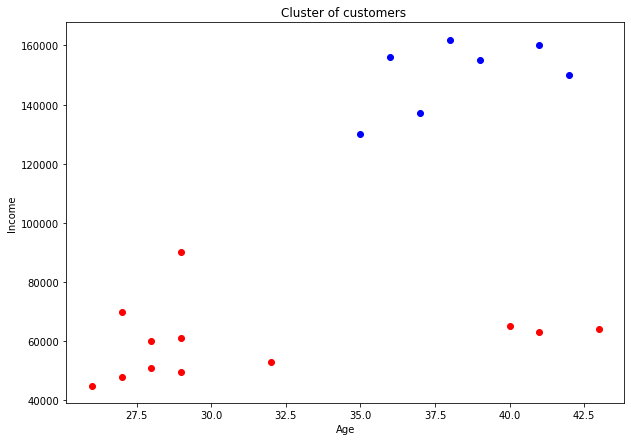

In [22]:
x=datasubset.values
plt.figure(figsize=(10,7))
plt.scatter(x[cl==0,0],x[cl==0,1],c='red',label='cluster1')
plt.scatter(x[cl==1,0],x[cl==1,1],c='blue',label='cluster2')
plt.title('Cluster of customers ')
plt.xlabel('Age')
plt.ylabel('Income')
plt